In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#Lets create synthetic data points
from sklearn.datasets import make_classification

In [4]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [5]:
X

array([[-1.23111071, -0.98564409],
       [-1.75477994, -0.87037495],
       [ 2.94460423, -2.86621378],
       ...,
       [-0.61588257,  1.2789664 ],
       [ 0.87593631,  1.00018079],
       [ 0.43748186, -0.10697958]], shape=(1000, 2))

In [6]:
pd.DataFrame(X)[0]

0     -1.231111
1     -1.754780
2      2.944604
3      0.457129
4      0.550392
         ...   
995    0.741212
996    1.048867
997   -0.615883
998    0.875936
999    0.437482
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

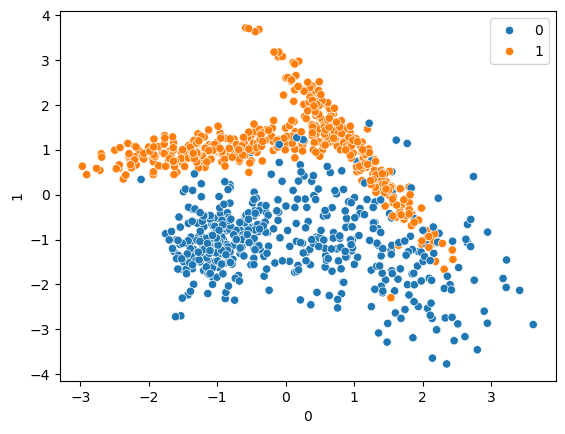

In [7]:
sns.scatterplot(x=pd.DataFrame(X)[0] ,y=pd.DataFrame(X)[1] ,hue=y)

In [8]:
from sklearn.svm import SVC

In [9]:
svc = SVC(kernel='linear')

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score,classification_report
acc = accuracy_score(y_pred,y_test)
print(acc)
print(classification_report(y_pred,y_test))


0.9
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       131
           1       0.90      0.89      0.89       119

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250



In [14]:
rbf=SVC(kernel='rbf')
rbf.fit(X_train,y_train)
y_pred = rbf.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print(acc)
print(classification_report(y_pred,y_test))

0.956
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       125
           1       0.98      0.93      0.95       125

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [15]:
poly=SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred = poly.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print(acc)
print(classification_report(y_pred,y_test))

0.92
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       134
           1       0.91      0.92      0.91       116

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250



In [16]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
y_pred = sigmoid.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print(acc)
print(classification_report(y_pred,y_test))

0.772
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       129
           1       0.77      0.75      0.76       121

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



In [17]:
#HyperParameter tunning for SVC
from sklearn.model_selection import GridSearchCV
param_grid = {'C':[0.1,1,10,100,1000],
              'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}

In [20]:
grid = GridSearchCV(SVC(),param_grid=param_grid,cv=5,refit=True,verbose=3)

In [21]:
grid.fit(X_train,y_train)
y_pred = grid.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print(acc)
print(classification_report(y_pred,y_test))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.920 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

In [22]:
grid.best_params_

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}